# Supplementary Figure S34: `s34_robadvctl_alignment`

This notebook rebuilds the figure step by step from its script, `figures/supplementary/sup_robadvctl_alignment.py`. Every code cell below is a verbatim slice of that file, in the order the file defines it: first the imports and configuration, then each helper function with a short explanation, then the body of `main()` laid out as the assembly of the panels, and finally the rendered figure with its caption. Run the cells top to bottom; in the reference environment the PNG written at the end is identical to the submitted manuscript file (see docs/REPRODUCIBILITY.md).

Axis alignment measures how much of a parametric sweep actually lands on the encoding axis, expressed as a per-dimension displacement ratio and averaged over the ten seeds of each site-model. If adversarially trained models simply produce better-aligned sweeps, that alone might explain their control advantage. This figure first shows the association between alignment and control across the trained site-models, then repeats the per-model comparison with alignment regressed out, and finally compares the raw and alignment-adjusted family gaps. Alignment comes from the loader's axis-alignment cache and the outcomes from the control table.

## What the script says about itself

Supp fig (robadvctl_alignment) - relationship between encoding-axis alignment and neural control outcomes, and the control comparison with alignment regressed out.

Axis alignment (per-dim displacement ratio, seed-averaged per site-model) is a post-treatment property produced by training, so the adjusted comparison is a sensitivity analysis. Residuals use coefficients from the JOINT model `outcome ~ C(model) + align + C(site)` so model structure is never absorbed into the alignment slope; site variance stays in the display.

a,b Axis alignment vs control r / control slope across the 225 trained site-models (pooled fit line + Pearson r). c,d Control r / control slope with alignment regressed out, by model (per-model swarms + means, all 10 models, sorted by residual mean).

- **(e)** Summary: raw adv-vs-conventional gap (site-fixed-effects Delta among the 9 trained models, p = within-site paired Wilcoxon over 25 sites) vs the alignment-ADJUSTED gap (ANCOVA `outcome ~ adv + align + C(site)`, site-clustered p). Untrained is shown in c,d but never enters the family tests.

Reads loader.load_axis_alignment() + control_table().

## 1. Environment

A few lines that are not in the script: they make the notebook render exactly like the command-line harness does (single-threaded BLAS, the Agg backend with matplotlib defaults, the repository on the import path) and check that the preprocessed data are present.

In [1]:
import os, sys
from pathlib import Path

# Keep BLAS single-threaded: multithreaded OpenMP together with torch can kill the kernel on macOS.
for _v in ('OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS', 'VECLIB_MAXIMUM_THREADS'):
    os.environ.setdefault(_v, '1')
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

# Render with the Agg backend and matplotlib's defaults, exactly like the figure scripts;
# Jupyter's inline backend would otherwise change dpi and bounding boxes.
os.environ['MPLBACKEND'] = 'Agg'
import matplotlib; matplotlib.use('Agg'); matplotlib.rcdefaults()

# Work from the repository root whether the notebook is opened there or in notebooks/figures/.
REPO = Path.cwd() if (Path.cwd() / 'pnc').exists() else Path.cwd().parents[1]
sys.path.insert(0, str(REPO))
from pnc import paths

# The figures read the preprocessed caches only; this raises a clear message if they are missing.
paths.require(paths.preprocessed_data() / 'brain_red.pkl')   # python data/download_data.py --tier preprocessed
OUT_DIR = paths.output_dir() / 'figures'
OUT_DIR.mkdir(parents=True, exist_ok=True)

## 2. Imports, style and configuration

The script starts by importing the study configuration and figure style from `pnc` (colours, model names, the publication rcParams) and the cache loader, then fixes the constants that the panels share: which sites and models are shown, layout sizes, colour choices, and where the inputs live. `apply_figure_style()` is what makes every figure in the paper look the same.

`OUTCOMES` lists control `r` and control slope, `ROBUST` the two adversarially trained models, and `UNTR` the untrained baseline, which is excluded from the scatter panels and the family tests but shown in the per-model panels. `C_ADJ` colors the adjusted bars.

In [2]:
import os

import numpy as np

import pandas as pd

from scipy import stats

import matplotlib

matplotlib.use('Agg')

import matplotlib.pyplot as plt

from matplotlib.gridspec import GridSpec

from pnc import paths

from pnc.utils import (apply_figure_style, FONT_FAMILY, MM, WIDTH_2COL_MM, FIG_FACECOLOR,
                       save_fig, MODEL_SHORT_NAMES, ROBUST_MODELS, get_model_color)

from pnc.manifest import fig as _fig, output_name

from pnc.preproc import loader as L

from pnc.famstats import adv_gap, partial_residuals, stars as _sig_stars

apply_figure_style()

STEM = output_name('robadvctl_alignment')

UNTR = 'AlexNet_training_seed_01'

SHORT = dict(MODEL_SHORT_NAMES); SHORT[UNTR] = 'Untrained'



ROBUST = set(ROBUST_MODELS)

FS_TITLE, FS_AX, FS_TICK, FS_ANNOT, FS_LETTER = 7, 6.5, 5.5, 5, 10

OUTCOMES = [('control_r', 'Control $r$'), ('control_slope', 'Control slope')]

C_ADJ = '#E1812C'

## 3. The building blocks

Each function below is one component of the figure: loading and shaping a cache, computing a statistic, or drawing one panel into an axes it is handed. They are defined here exactly as in the script and used by the assembly in the last section; read them in order, the assembly calls them in roughly the same order.

`build` assembles the table and residuals; `scatter_panel`, `per_model_panel` and `summary_panel` draw the three panel types, using the shared `adv_gap` and `partial_residuals` helpers for statistics.

### `build()`

All-10 table with per-site alignment + joint-model residuals; `robust` int flag.

Computes the alignment ratio for every (site, model, seed) record, averages it per site-model, and joins it to the control outcomes, keeping only rows where both outcomes are finite. It then adds partial residuals for each outcome from a joint model with model and site terms, removing only the alignment effect.

In [3]:
def build():
    """All-10 table with per-site alignment + joint-model residuals; `robust` int flag."""
    a = L.load_axis_alignment()
    mk, un, mo = np.array(a['monkey']), np.array(a['unit']), np.array(a['model'])
    ratio = a['DM'] / (a['DOM'] / np.sqrt(a['n_off']))
    agg = {}
    for i in range(len(ratio)):
        agg.setdefault((str(mk[i]), int(un[i]), str(mo[i])), []).append(ratio[i])
    align = {k: float(np.mean(v)) for k, v in agg.items()}     # seed-averaged per site-model

    ct = L.control_table(); rows = []
    for _, r in ct.iterrows():
        k = (r['monkey'], int(r['unit']), r['model'])
        if k in align and np.isfinite(r['control_r']) and np.isfinite(r['control_slope']):
            rows.append(dict(monkey=r['monkey'], unit=int(r['unit']), model=r['model'],
                             align=align[k], control_r=float(r['control_r']),
                             control_slope=float(r['control_slope']),
                             robust=int(r['model'] in ROBUST)))
    df = pd.DataFrame(rows)
    for y, _ in OUTCOMES:
        # joint-model partial residuals: alignment effect removed, model + site structure kept
        df[y + '_res'] = partial_residuals(df, y, ('align',), keep='model', remove_site=False)
    return df

### `_spines(ax)`

In [4]:
def _spines(ax):
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)

### `scatter_panel(ax, tr, ycol, ylab)`

Alignment vs control outcome across the 225 trained site-models (pooled fit).

Plots alignment against one outcome for the trained site-models, colored by model with adversarially trained points outlined in black, and adds a pooled fit with Pearson `r`, p-value and n in a corner box.

In [5]:
def scatter_panel(ax, tr, ycol, ylab):
    """Alignment vs control outcome across the 225 trained site-models (pooled fit)."""
    x, y = tr['align'].values, tr[ycol].values
    for _, r in tr.iterrows():
        ax.scatter(r['align'], r[ycol], s=9, color=get_model_color(r['model']),
                   edgecolors=('black' if r['robust'] else 'white'),
                   linewidths=(0.55 if r['robust'] else 0.2), alpha=0.85, zorder=3)
    b = np.polyfit(x, y, 1); xs = np.array([x.min(), x.max()])
    ax.plot(xs, np.polyval(b, xs), color='#333', lw=1.0, zorder=4)
    rr, pp = stats.pearsonr(x, y)
    ax.text(0.97, 0.04, f'$r$ = {rr:+.2f}\n$p$ = {pp:.0e}\n$n$ = {len(tr)}',
            transform=ax.transAxes, va='bottom', ha='right', fontsize=FS_ANNOT,
            fontfamily=FONT_FAMILY, linespacing=1.25,
            bbox=dict(boxstyle='round', fc='white', ec='#ccc', alpha=0.85))
    ax.set_xlabel('Axis alignment (per-dim displacement ratio)', fontsize=FS_AX)
    ax.set_ylabel(ylab, fontsize=FS_AX)
    ax.tick_params(labelsize=FS_TICK); _spines(ax)

### `per_model_panel(ax, df, y, ylabel)`

Orders all ten models by their adjusted mean and shows each model's residuals as a swarm, with a gray bar for the raw mean and a black bar for the alignment-adjusted mean.

In [6]:
def per_model_panel(ax, df, y, ylabel):
    col = y + '_res'
    order = df.dropna(subset=[col]).groupby('model')[col].mean().sort_values().index.tolist()
    rng = np.random.default_rng(0)
    for xi, mdl in enumerate(order):
        d = df[df.model == mdl].dropna(subset=[col])
        ax.scatter(xi + rng.uniform(-0.28, 0.28, len(d)), d[col], s=6, color=get_model_color(mdl),
                   alpha=0.85, edgecolors='white', linewidths=0.2, zorder=4)
        ax.plot([xi - 0.34, xi + 0.34], [d[y].mean()] * 2, color='#b0b0b0', lw=1.2, zorder=5)
        ax.plot([xi - 0.34, xi + 0.34], [d[col].mean()] * 2, color='black', lw=1.2, zorder=6)
    ax.axhline(0, color='#888', lw=0.8, ls='--', zorder=1)
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels([SHORT[mm] for mm in order], rotation=45, ha='right', fontsize=FS_TICK)
    for t, mm in zip(ax.get_xticklabels(), order):
        t.set_color(get_model_color(mm)); t.set_fontweight('bold' if mm in ROBUST else 'normal')
    ax.set_ylabel(ylabel + ', alignment regressed out', fontsize=FS_AX)
    ax.set_title(ylabel + ' residuals by model', fontsize=FS_TITLE, fontweight='bold',
                 fontfamily=FONT_FAMILY, pad=4)
    ax.tick_params(axis='y', labelsize=FS_TICK); _spines(ax)

### `summary_panel(ax, df)`

Raw (site-FE, within-site Wilcoxon) vs alignment-adjusted (ANCOVA, site-clustered p), among the 9 trained models.

For each outcome, bars for the raw adversarial-minus-conventional gap (within-site Wilcoxon p) and the alignment-adjusted gap (ANCOVA with site fixed effects and clustered errors), with significance stars.

In [7]:
def summary_panel(ax, df):
    """Raw (site-FE, within-site Wilcoxon) vs alignment-adjusted (ANCOVA, site-clustered
    p), among the 9 trained models."""
    x = np.arange(len(OUTCOMES)); w = 0.34
    for k, (y, _) in enumerate(OUTCOMES):
        raw = adv_gap(df, y)
        adj = adv_gap(df, y, covariates=('align',))
        for j, (g, c, lab) in enumerate([(raw, '#CCCCCC', 'Raw'),
                                         (adj, C_ADJ, 'alignment-adjusted')]):
            xx = k + (j - 0.5) * w
            ax.bar(xx, g['delta'], w * 0.9, color=c, edgecolor='black', linewidth=0.4,
                   label=(lab if k == 0 else None))
            ax.text(xx, g['delta'] + 0.008, _sig_stars(g['p']),
                    ha='center', va='bottom', fontsize=FS_TICK)
    ax.set_xticks(x); ax.set_xticklabels([lab for _, lab in OUTCOMES], fontsize=FS_TICK)
    ax.set_ylabel(r'(Adv. $-$ conventional training)', fontsize=FS_AX)
    ax.set_title('Summary: baseline vs. adjusted', fontsize=FS_TITLE, fontweight='bold',
                 fontfamily=FONT_FAMILY, pad=4)
    ax.set_ylim(top=ax.get_ylim()[1] * 1.30)
    ax.legend(fontsize=FS_ANNOT, frameon=False, loc='upper center', ncol=1, columnspacing=1.0,
              labelspacing=0.3, handlelength=1.0, handletextpad=0.35, bbox_to_anchor=(0.5, 1.02))
    ax.tick_params(labelsize=FS_TICK); _spines(ax)

## 4. Assembling the figure

This is the body of `main()` from the script, laid out step by step: it builds the figure canvas, calls the building blocks to fill each panel, and saves the result with `save_fig`, which trims the white border so the file matches the submitted figure.

Two grid rows: the top has the two alignment scatters, the bottom the two per-model panels and the summary. The table is built once, the trained subset is taken for the scatters, panels are drawn, and letters, title and a mean-bar legend are placed after a draw pass.

In [8]:
# Inputs of the assembly below (these are the parameters of main() in the script).
out_dir = str(OUT_DIR)

**Step 1**

Builds the full table and extracts the trained-model subset used by the scatter panels.

In [9]:
df = build()
tr = df[df.model != UNTR]

**Step 2**

Creates the two grids and fills the alignment-versus-`r` and alignment-versus-slope scatters (with titles), the two adjusted per-model panels, and the summary.

In [10]:
fig = plt.figure(figsize=(WIDTH_2COL_MM * MM, 124 * MM), facecolor=FIG_FACECOLOR)
gs_top = GridSpec(1, 2, figure=fig, left=0.07, right=0.985, top=0.885, bottom=0.615,
                  wspace=0.30)
gs_bot = GridSpec(1, 3, figure=fig, left=0.07, right=0.985, top=0.46, bottom=0.175,
                  wspace=0.42, width_ratios=[1.3, 1.3, 0.85])
letters = []
a = fig.add_subplot(gs_top[0, 0]); scatter_panel(a, tr, 'control_r', 'Control $r$'); letters.append(a)
a.set_title('Axis alignment vs control $r$', fontsize=FS_TITLE, fontweight='bold',
            fontfamily=FONT_FAMILY, pad=4)
a = fig.add_subplot(gs_top[0, 1]); scatter_panel(a, tr, 'control_slope', 'Control slope'); letters.append(a)
a.set_title('Axis alignment vs control slope', fontsize=FS_TITLE, fontweight='bold',
            fontfamily=FONT_FAMILY, pad=4)
a = fig.add_subplot(gs_bot[0, 0]); per_model_panel(a, df, 'control_r', 'Control $r$'); letters.append(a)
a = fig.add_subplot(gs_bot[0, 1]); per_model_panel(a, df, 'control_slope', 'Control slope'); letters.append(a)
a = fig.add_subplot(gs_bot[0, 2]); summary_panel(a, df); letters.append(a)

**Step 3**

Places letters and the figure title, adds the raw-versus-adjusted mean legend between the rows, and prints the raw and adjusted gaps with p-values.

In [11]:
fig.canvas.draw()
for ax, L_ in zip(letters, 'abcde'):
    bb = ax.get_position()
    dx = 0.050 if L_ == 'e' else 0.036
    fig.text(bb.x0 - dx, bb.y1 + 0.012, L_, ha='left', va='bottom', fontsize=FS_LETTER,
             fontweight='bold', fontfamily=FONT_FAMILY)
fig.text(0.5, 0.975, 'Relationship between axis alignment and neural control outcomes',
         ha='center', va='top', fontsize=FS_TITLE, fontweight='bold', fontfamily=FONT_FAMILY)
from matplotlib.lines import Line2D
fig.legend(handles=[Line2D([0], [0], color='#b0b0b0', lw=1.4, label='raw mean'),
                    Line2D([0], [0], color='black', lw=1.4, label='mean, alignment regressed out')],
           fontsize=FS_ANNOT, frameon=False, ncol=2, loc='upper center',
           bbox_to_anchor=(0.40, 0.535), handlelength=1.2, handletextpad=0.4, columnspacing=1.4)

# console: raw vs adjusted gaps
for y, lab in OUTCOMES:
    raw = adv_gap(df, y); adj = adv_gap(df, y, covariates=('align',))
    print(f'{lab}: raw D={raw["delta"]:+.3f} (p={raw["p"]:.2g}, {raw["test"]}) | '
          f'alignment-adjusted D={adj["delta"]:+.3f} (p={adj["p"]:.2g}, {adj["test"]})')

Control $r$: raw D=+0.245 (p=1.2e-07, within-site paired Wilcoxon) | alignment-adjusted D=+0.254 (p=8.1e-17, site-FE ANCOVA, site-clustered)
Control slope: raw D=+0.250 (p=6e-08, within-site paired Wilcoxon) | alignment-adjusted D=+0.260 (p=1.2e-14, site-FE ANCOVA, site-clustered)


**Step 4**

Saves and closes the figure; `png` receives the path.

In [12]:
path = save_fig(fig, os.path.join(out_dir, STEM))
plt.close(fig)
print('Saved ->', path)
png = path

Saved -> /private/tmp/claude-501/-Users-jacobprince-KonkLab-Dropbox-Jacob-Prince-Research-Prince-Accentuate-VVS-Manuscript/bca6882d-ec2d-4dbd-beb1-0d67d8b1fcc7/scratchpad/nb_exec_out/figures/s34_robadvctl_alignment.png


## 5. The figure

`png` now points at the rendered file. A downscaled preview follows (the full-resolution PNG is the file itself, `s34_robadvctl_alignment.png` in the output directory).

The scatters should show a weak positive slope, enough to justify adjusting. In the bottom row the model ordering should be preserved after adjustment, with the two bold models still highest, and all four summary bars positive and starred.

/private/tmp/claude-501/-Users-jacobprince-KonkLab-Dropbox-Jacob-Prince-Research-Prince-Accentuate-VVS-Manuscript/bca6882d-ec2d-4dbd-beb1-0d67d8b1fcc7/scratchpad/nb_exec_out/figures/s34_robadvctl_alignment.png


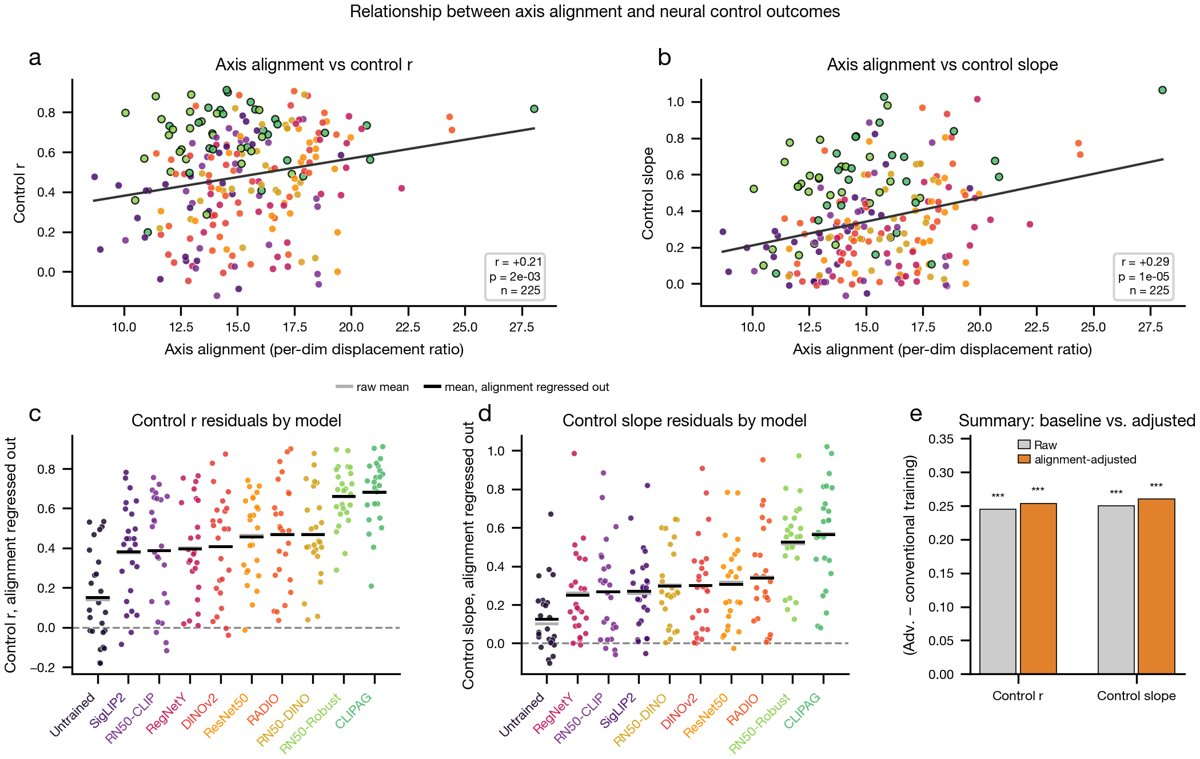

In [13]:
import io
from IPython.display import Image, display
from PIL import Image as PILImage

# A JPEG preview keeps the notebook small; open the PNG for full detail.
print(png)
im = PILImage.open(png).convert("RGB")
im.thumbnail((1200, 1200))
buf = io.BytesIO(); im.save(buf, "JPEG", quality=85, optimize=True)
display(Image(data=buf.getvalue(), format="jpeg", width=900))

**Supplementary Figure S34. Relationship between axis alignment and neural control outcomes.** For each model-channel, axis alignment is the per-dimension displacement ratio $\mathrm{DM}/(\mathrm{DOM}/\sqrt{n_{\text{off}}})$, seed-averaged over the 10 accentuation seeds, quantifying how much of each parametric sweep lands on the encoding axis. (A) Control score ($r$) versus axis alignment across the trained model-channels ($n = 225$; $9$ trained models, Untrained excluded), dots colored by model with adversarially trained models (ResNet50-Robust, CLIPAG) outlined in black; OLS fit and Pearson $r = +0.21$ ($p = 2\times10^{-3}$). (B) Same for control slope, $r = +0.29$ ($p = 1\times10^{-5}$). Alignment is weakly but positively associated with control, motivating adjustment. (C, D) Control $r$ (C) and control slope (D) with alignment regressed out, one dot per site-model across all $10$ models (alignment effects removed via a joint OLS fit with model and site terms, grand mean restored); black bars, alignment-adjusted model means; gray bars, raw means. The model ordering is preserved, with the two adversarially trained models remaining highest. (E) Adversarially-trained-minus-conventional group-mean gap for control $r$ and control slope among the $9$ trained models, raw (gray; $p$ from a within-site paired Wilcoxon over the $25$ sites) versus alignment-adjusted (orange; ANCOVA with site fixed effects and site-clustered errors); all four gaps are positive and significant ($\ast\ast\ast p < 10^{-3}$), showing the adversarially trained models' advantage is not explained by greater on-axis displacement.